# BM25 Retrieval

This notebook implements a BM25-based retrieval system for the course material from **Verifikacija softvera**.

The retrieval system indexes preprocessed text chunks and retrieves the most relevant chunks for a given question. Retrieval performance is evaluated using MRR, Hit@K, Precision@K, Recall@K, and nDCG@K.


In [14]:
%pip install -q rank-bm25

from pathlib import Path
import json
import math
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from rank_bm25 import BM25Okapi

from typing import List, Dict, Set


pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)

Note: you may need to restart the kernel to use updated packages.


In [15]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else PROJECT_ROOT
    )

CHUNKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "chunks_preprocessed.jsonl"
)

SPLIT_PATHS = {
    "train": PROJECT_ROOT / "data" / "splits" / "train.jsonl",
    "validation": PROJECT_ROOT / "data" / "splits" / "validation.jsonl",
    "test": PROJECT_ROOT / "data" / "splits" / "test.jsonl",
}

K_VALUES = [1, 3, 5, 10]
TOP_K = 5

TOKEN_PATTERN = re.compile(r"[\w]+", re.UNICODE)

print(f"Project root: {PROJECT_ROOT.resolve()}")

Project root: /home/anja/Desktop/MU/Student-Question-Answering-from-Course-Materials


In [16]:
def load_jsonl(path: Path) -> List[Dict]:
    records = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Neispravan JSON u redu {line_number}: {path}"
                ) from error

    return records


chunks = load_jsonl(CHUNKS_PATH)

train_data = load_jsonl(
    SPLIT_PATHS["train"]
)

validation_data = load_jsonl(
    SPLIT_PATHS["validation"]
)

test_data = load_jsonl(
    SPLIT_PATHS["test"]
)


print(f"Chunkovi: {len(chunks)}")

print(
    f"Train/validation/test: "
    f"{len(train_data)}/{len(validation_data)}/{len(test_data)}"
)

pd.DataFrame(chunks).head(2)[
    [
        "chunk_id",
        "pdf_page_start",
        "pdf_page_end"
    ]
]

Chunkovi: 163
Train/validation/test: 100/21/22


,chunk_id,pdf_page_start,pdf_page_end
0,chunk_0001,17,18
1,chunk_0002,18,19


In [17]:
def normalize_for_bm25(text: str) -> str:
    text = unicodedata.normalize("NFKC", text or "")
    text = text.replace("�", "")
    text = re.sub(r"(?<=\w)-\s*(?=\w)", "", text)
    return text.lower()


def tokenize(text: str) -> List[str]:
    return TOKEN_PATTERN.findall(
        normalize_for_bm25(text)
    )


assert chunks, "Korpus chunkova je prazan."

required_fields = {
    "chunk_id",
    "pdf_page_start",
    "pdf_page_end"
}

assert required_fields.issubset(
    chunks[0]
), "Nedostaju metadata polja chunk-a."

assert len(
    {chunk["chunk_id"] for chunk in chunks}
) == len(chunks), "chunk_id mora biti jedinstven."


documents = [
    chunk.get("processed_text") or chunk.get("text", "")
    for chunk in chunks
]

assert all(
    document.strip()
    for document in documents
), "Korpus sadrži prazan chunk."


tokenized_documents = [
    tokenize(document)
    for document in documents
]


print(
    f"Prosečan broj tokena po chunk-u: "
    f"{sum(map(len, tokenized_documents)) / len(tokenized_documents):.1f}"
)

Prosečan broj tokena po chunk-u: 324.3


In [18]:
bm25_index = BM25Okapi(
    tokenized_documents
)

print(
    f"BM25 index created for "
    f"{len(tokenized_documents)} chunks."
)

BM25 index created for 163 chunks.


In [19]:
def retrieve(
    question: str,
    top_k: int = TOP_K
) -> List[Dict]:

    if not isinstance(question, str) or not question.strip():
        raise ValueError(
            "Pitanje ne sme biti prazno."
        )

    number_of_results = min(
        max(top_k, 1),
        len(chunks)
    )

    scores = bm25_index.get_scores(
        tokenize(question)
    )

    ranked_indices = sorted(
        range(len(scores)),
        key=lambda index: scores[index],
        reverse=True
    )[:number_of_results]

    return [
        {
            "rank": rank,
            "chunk_id": chunks[index]["chunk_id"],
            "score": float(scores[index]),
            "text": documents[index],
            "pdf_page_start": chunks[index].get(
                "pdf_page_start"
            ),
            "pdf_page_end": chunks[index].get(
                "pdf_page_end"
            ),
            "section_ref": chunks[index].get(
                "section_ref"
            ),
            "heading": chunks[index].get(
                "heading"
            ),
        }
        for rank, index in enumerate(
            ranked_indices,
            start=1
        )
    ]

In [20]:
example = test_data[0]

example_results = retrieve(
    example["processed_question"],
    TOP_K
)

pd.DataFrame(example_results)[
    [
        "rank",
        "chunk_id",
        "score",
        "pdf_page_start",
        "pdf_page_end"
    ]
]

,rank,chunk_id,score,pdf_page_start,pdf_page_end
0,1,chunk_0107,10.992920,139,140
1,2,chunk_0059,6.068536,80,81
2,3,chunk_0106,4.926908,138,139
3,4,chunk_0096,4.702081,126,128
4,5,chunk_0100,4.678445,131,133


In [21]:
def relevant_chunk_ids(
    source_pages: List[int]
) -> Set[str]:

    return {
        chunk["chunk_id"]
        for chunk in chunks
        if any(
            chunk["pdf_page_start"] <= page <= chunk["pdf_page_end"]
            for page in source_pages
        )
    }


def reciprocal_rank(
    retrieved_ids: List[str],
    relevant_ids: Set[str]
) -> float:

    for rank, chunk_id in enumerate(
        retrieved_ids,
        start=1
    ):
        if chunk_id in relevant_ids:
            return 1.0 / rank

    return 0.0

In [22]:
def evaluate_retrieval(
    questions: List[Dict],
    k_values: List[int] = K_VALUES
) -> pd.DataFrame:

    rows = []

    for item in questions:

        relevant = relevant_chunk_ids(
            item["source_pages"]
        )

        if not relevant:
            continue

        retrieved_ids = [
            result["chunk_id"]
            for result in retrieve(
                item["processed_question"],
                len(chunks)
            )
        ]

        row = {
            "id": item["id"],
            "question": item["processed_question"],
            "num_relevant": len(relevant),
            "mrr": reciprocal_rank(
                retrieved_ids,
                relevant
            )
        }

        for k in k_values:

            top_ids = retrieved_ids[:k]

            hits = sum(
                chunk_id in relevant
                for chunk_id in top_ids
            )

            ideal_hits = min(
                len(relevant),
                k
            )

            dcg = sum(
                1 / math.log2(rank + 1)
                for rank, chunk_id in enumerate(
                    top_ids,
                    start=1
                )
                if chunk_id in relevant
            )

            idcg = sum(
                1 / math.log2(rank + 1)
                for rank in range(
                    1,
                    ideal_hits + 1
                )
            )

            row.update({
                f"hit@{k}": float(bool(hits)),
                f"precision@{k}": (
                    hits / max(len(top_ids), 1)
                ),
                f"recall@{k}": (
                    hits / len(relevant)
                ),
                f"ndcg@{k}": (
                    dcg / idcg
                    if idcg
                    else 0.0
                )
            })

        rows.append(row)

    return pd.DataFrame(rows)

In [23]:
validation_results = evaluate_retrieval(
    validation_data
)

metric_columns = [
    column
    for column in validation_results.columns
    if column not in {
        "id",
        "question",
        "num_relevant"
    }
]

validation_summary = (
    validation_results[metric_columns]
    .mean()
    .to_frame(name="validation")
)

validation_summary

,validation
mrr,0.442848
hit@1,0.238095
precision@1,0.238095
recall@1,0.084921
ndcg@1,0.238095
hit@3,0.571429
precision@3,0.285714
recall@3,0.290476
ndcg@3,0.302841
hit@5,0.761905


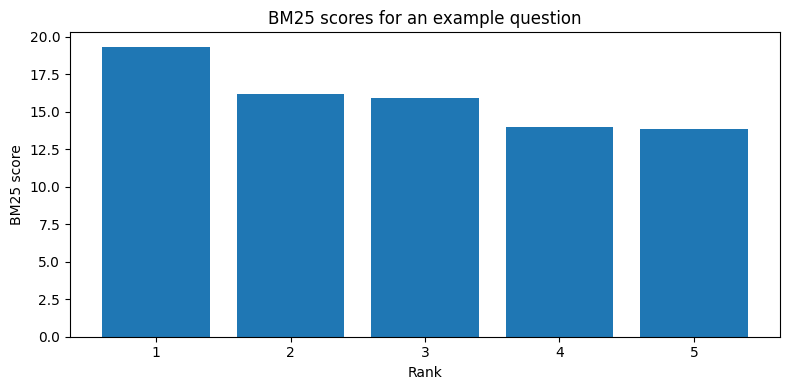

In [24]:
demo_results = retrieve(
    validation_data[0]["processed_question"],
    TOP_K
)

score_values = [
    result["score"]
    for result in demo_results
]

plt.figure(figsize=(8, 4))

plt.bar(
    range(1, len(score_values) + 1),
    score_values
)

plt.xlabel("Rank")
plt.ylabel("BM25 score")
plt.title("BM25 scores for an example question")

plt.xticks(
    range(1, len(score_values) + 1)
)

plt.tight_layout()
plt.show()

In [25]:
question = "Šta je verifikacija softvera?"

results = retrieve(question, top_k=5)

for result in results:
    print(f"\n--- Rank {result['rank']} ---")
    print(f"Chunk ID: {result['chunk_id']}")
    print(f"BM25 score: {result['score']:.4f}")
    print(f"PDF page: {result['pdf_page_start']} - {result['pdf_page_end']}")
    print(f"Heading: {result['heading']}")
    print(f"\n{result['text'][:1000]}")


--- Rank 1 ---
Chunk ID: chunk_0040
BM25 score: 9.1016
PDF page: 57 - 61
Heading: None

[Tehnike verifikacije softvera]

kacija softvera obuhvata sve procese koji su potrebni da se osigura da razvijeni softver zadovoljava zadatu specifikaciju. -I verifikacija i validacija su od suštinske važnosti za kvalitet softvera.

-Verifikacija softvera može da bude dinamička i statička. -Dinamička verifikacija softvera se oslanja pre svega na testiranje, ali testiranje ne može da garantuje ispravnost softvera. -Statička verifikacija softvera uključuje ljudske preglede koda i formalne metode. -Automatska statička verifikacija: neophodni su kompromisi između preciznosti i efikasnosti. -Razvoj direktno iz specifikacije i formalno dokazivanje ispravnosti softvera koristi se za razvoj kritičnih delova aplikacija. Literatura [1] Paul Ammann i Jeff Offutt. Introduction to Software Testing. Cambridge University Press, 2017. doi: 10.1017/9781316771273. [2] Antonia Bertolino. Software Testing Research: Ac

In [26]:
test_questions = [
    "Šta je verifikacija softvera?",
    "Šta je validacija softvera?",
    "Šta je model sistema?",
    "Koja je razlika između verifikacije i validacije?",
    "Šta je formalna verifikacija?"
]

for question in test_questions:
    print("=" * 100)
    print(f"PITANJE: {question}")

    results = retrieve(question, top_k=5)

    for result in results:
        print(
            f"\nRank {result['rank']} | "
            f"Score: {result['score']:.4f} | "
            f"Pages: {result['pdf_page_start']}-{result['pdf_page_end']}"
        )
        print(result["text"][:500])

PITANJE: Šta je verifikacija softvera?

Rank 1 | Score: 9.1016 | Pages: 57-61
[Tehnike verifikacije softvera]

kacija softvera obuhvata sve procese koji su potrebni da se osigura da razvijeni softver zadovoljava zadatu specifikaciju. -I verifikacija i validacija su od suštinske važnosti za kvalitet softvera.

-Verifikacija softvera može da bude dinamička i statička. -Dinamička verifikacija softvera se oslanja pre svega na testiranje, ali testiranje ne može da garantuje ispravnost softvera. -Statička verifikacija softvera uključuje ljudske preglede koda i formalne metode. 

Rank 2 | Score: 7.4173 | Pages: 54-55
[Verifikacija i validacija softvera > 3.2 Tehnike verifikacije softvera]

i opisa vremenskih uslova, prikazuju u odgovarajućem i očekivanom formatu. Pored toga, proverava se i da li aplikacija ispravno prikazuje vremenske podatke za različite lokacije, bilo da su one definisane nazivima gradova ili geografskim koordinatama. Validacija predstavlja postupak kojim se utvrđuje da li 